# Route Roulette — Hack4Rail 2026
## SBB Jura Network: Budget Allocation Analysis at Section (Strecken) Level

**Context:** The existing MIAM model scores every ~200 m asset chunk across the Swiss railway network on condition,
remaining lifecycle and replacement value, then allocates a national budget envelope across sections.
This notebook focuses on the **Jura sub-network** (lines 200–230, Lausanne arc → Basel via Jura)
and surfaces the key parameters that drive investment priority at the **Strecken level**.

### Data files used
| File | Content |
|---|---|
| `Teilnetz_Invest_Resultate_V24_1300MCHF_Chunk200.xlsx` — sheet *Gesamtnetz* | Master list of 29 Jura sections |
| `Teilnetz_Invest_Resultate_V24_1300MCHF_Chunk200.xlsx` — sheet *Entwicklung_Teilnetz (1)* | Per-asset simulation data (54 k rows, 54 cols) for the Jura network |
| `Auswertung_ER_...` — sheet *Basisdaten* | Renewal-risk (ER) budget need & allocation per section/year |
| `Auswertung_IR_...` — sheet *Basisdaten* | Investment-risk (IR) renewal costs & allocation per section/year |

## 1 · Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.0f}".format)

DATA_DIR = Path("data/version_limited_ressources/C200")

print("Libraries loaded ✓")

Libraries loaded ✓


## 2 · Load Data Files as Pandas DataFrames

Four files are loaded:
- **`df_sections`** — master list of the 29 Jura network sections
- **`df_assets`** — full per-asset simulation data for the Jura sub-network (source of truth for condition & costs)
- **`df_er`** — renewal-risk (ER) budget allocation per section × year
- **`df_ir`** — investment-risk (IR) renewal costs per section × year

In [2]:
RESULTS_FILE = DATA_DIR / "Teilnetz_Invest_Resultate_V24_1300MCHF_Chunk200.xlsx"
ER_FILE      = DATA_DIR / "Auswertung_ER_2025_V22_002_Fokus_Top_Hauptstrecken_VTHP50_1300MCHF_AB_Chunk200.xlsx"
IR_FILE      = DATA_DIR / "Auswertung_IR_2025_V22_002_Fokus_Top_Hauptstrecken_VTHP50_1300MCHF_AB_Chunk200.xlsx"

# Master section list (29 rows)
df_sections = pd.read_excel(RESULTS_FILE, sheet_name="Gesamtnetz")

# Per-asset simulation data — Jura sub-network (54 k rows, all years 2025-2050)
df_assets = pd.read_excel(RESULTS_FILE, sheet_name="Entwicklung_Teilnetz (1)")

# Renewal-risk (ER) budget allocation
df_er = pd.read_excel(ER_FILE, sheet_name="Basisdaten")

# Investment-risk (IR) renewal costs
df_ir = pd.read_excel(IR_FILE, sheet_name="Basisdaten")

print(f"df_sections : {df_sections.shape}")
print(f"df_assets   : {df_assets.shape}")
print(f"df_er       : {df_er.shape}")
print(f"df_ir       : {df_ir.shape}")

df_sections : (28, 12)
df_assets   : (54735, 54)
df_er       : (237900, 10)
df_ir       : (30348, 10)


## 3 · DataFrame Heads and Basic Info

In [3]:
# --- Section master list ---
print("=== df_sections (Gesamtnetz — 29 sections) ===")
display(df_sections.head(5))

=== df_sections (Gesamtnetz — 29 sections) ===


,Streckenkategorie,Streckenkategorie Level 1,Streckenkategorie Level 2,Linie,Linie Level 1,Linie Level 2,Linie Level 3,Bewirtschaftungsraster,Bewirtschaftungsraster Level 1,Bewirtschaftungsraster Level 2,Bewirtschaftungsraster Level 3,Kostenstellen
0,200100,Hauptstrecke,200100 - (Renens) - (Bussigny),200100,Region 2xx,200 - Renens VD Ouest - Vallorbe,200100 - (Renens) - (Bussigny),200100,Strecken x,6 - (Renens VD) - Bussigny - Daillens (bif) - ...,200100 - (Renens) - (Bussigny),200100
1,200150,Hauptstrecke,200150 - Bussigny - Daillens [bif],200150,Region 2xx,200 - Renens VD Ouest - Vallorbe,200150 - Bussigny - Daillens [bif],200150,Strecken x,6 - (Renens VD) - Bussigny - Daillens (bif) - ...,200150 - Bussigny - Daillens [bif],200150
2,200200,Regionalstrecke,200200 - (Daillens) - (Le Day),200200,Region 2xx,200 - Renens VD Ouest - Vallorbe,200200 - (Daillens) - (Le Day),200200,Strecken x,9 - (Daillens (bif)) - Le Day - Vallorbe-Front...,200200 - (Daillens) - (Le Day),200200
3,200250,Regionalstrecke,200250 - Le Day - (Vallorbe),200250,Region 2xx,200 - Renens VD Ouest - Vallorbe,200250 - Le Day - (Vallorbe),200250,Strecken 8x,82 - (Le Day) - Le Pont,200250 - Le Day - (Vallorbe),200250
4,200300,Regionalstrecke,200300 - Vallorbe (communauté),200300,Region 2xx,203 - Frasne - Vallorbe,200300 - Vallorbe (communauté),200300,Strecken 8x,82 - (Le Day) - Le Pont,200300 - Vallorbe (communauté),200300


In [4]:
# --- Per-asset simulation data ---
print("=== df_assets (Entwicklung_Teilnetz — per asset, all years) ===")
print(f"Years covered: {sorted(df_assets['Betrachtungsjahr'].dropna().unique().astype(int).tolist())}")
print(f"Sections (Linie Level 3): {df_assets['Linie Level 3'].nunique()} unique")
print(f"Asset families (Gattungsname): {df_assets['Gattungsname'].nunique()} unique")
display(df_assets[["Linie Level 3", "Gattungsname", "Anlagentypname", "Betrachtungsjahr",
                    "Wiederbeschaffungswert (CHF)", "Substanz - Quality Aspect Grade",
                    "Zustandsklasse Substanz - Quality Aspect Grade",
                    "Effektive SOLL-Restlebensdauer absolut (Jahre)",
                    "Erneuerungskosten", "Erneuerung_laufendes_Jahr",
                    "Mittelverwendung_ER" if "Mittelverwendung_ER" in df_assets.columns else "Erneuerungskosten"]].head(5))

=== df_assets (Entwicklung_Teilnetz — per asset, all years) ===
Years covered: [2049, 2050]
Sections (Linie Level 3): 27 unique
Asset families (Gattungsname): 10 unique


,Linie Level 3,Gattungsname,Anlagentypname,Betrachtungsjahr,Wiederbeschaffungswert (CHF),Substanz - Quality Aspect Grade,Zustandsklasse Substanz - Quality Aspect Grade,Effektive SOLL-Restlebensdauer absolut (Jahre),Erneuerungskosten,Erneuerung_laufendes_Jahr,Erneuerungskosten
0,223100 - (Neuchâtel) - (La Chaux-de-Fonds),FB - Fahrbahn,Gleis,2049,"2,658",6,2,21,0,0,0
1,223100 - (Neuchâtel) - (La Chaux-de-Fonds),FB - Fahrbahn,Gleis,2049,"51,801",6,2,21,0,0,0
2,223100 - (Neuchâtel) - (La Chaux-de-Fonds),FB - Fahrbahn,Gleis,2049,"73,409",6,2,21,0,0,0
3,223100 - (Neuchâtel) - (La Chaux-de-Fonds),FB - Fahrbahn,Gleis,2049,"15,437",6,2,21,0,0,0
4,223100 - (Neuchâtel) - (La Chaux-de-Fonds),FB - Fahrbahn,Gleis,2049,"19,058",6,2,21,0,0,0


In [5]:
# --- ER and IR budget files ---
print("=== df_er (ER — renewal risk, budget allocation) ===")
display(df_er.head(3))
print("\n=== df_ir (IR — investment risk, renewal costs) ===")
display(df_ir.head(3))

=== df_er (ER — renewal risk, budget allocation) ===


,Streckenkategorie Level 1,Linie Level 2,Linie Level 3,Gattungsname,Anlagentypname,Betrachtungsjahr,Sum(ER_Anlage_Jahr),Count*(ER_Anlage_Jahr),Mittelverwendung,Ressourcenbedarf_Finanziell
0,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Beleuchtung_Tunnel,2025,114,1,ER,114
1,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Beleuchtung_Tunnel,2026,286,1,ER,286
2,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Beleuchtung_Tunnel,2027,286,1,ER,286



=== df_ir (IR — investment risk, renewal costs) ===


,Streckenkategorie Level 1,Linie Level 2,Linie Level 3,Gattungsname,Anlagentypname,Betrachtungsjahr,Sum(Erneuerungskosten),Count*(Erneuerungskosten),Mittelverwendung,Ressourcenbedarf_Finanziell
0,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Beleuchtung_Tunnel,2030,"57,200",1,IR,"57,200"
1,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Gleichrichter,2025,"50,000",2,IR,"50,000"
2,Hauptstrecke,100 - Lausanne - Simplon Tunnel I - Iselle,100260 - St-Maurice,BAI - Basisinfrastruktur,BAI_Gleichrichter,2029,"211,058",8,IR,"211,058"


## 4 · Data Summary Statistics

In [6]:
# Key numeric columns in the asset dataset (snapshot at year 2025)
assets_2025 = df_assets[df_assets["Betrachtungsjahr"] == 2025].copy()

key_cols = [
    "Wiederbeschaffungswert (CHF)",
    "Substanz - Quality Aspect Grade",
    "Zustandsklasse Substanz - Quality Aspect Grade",
    "Effektive SOLL-Restlebensdauer absolut (Jahre)",
    "Anlagenalter (Jahre)",
    "Erneuerungskosten",
]
print(f"Asset snapshot 2025: {len(assets_2025):,} rows across {assets_2025['Linie Level 3'].nunique()} sections\n")
display(assets_2025[key_cols].describe().T.round(2))

print("\n--- Route categories (Streckenkategorie Level 1) ---")
print(assets_2025["Streckenkategorie Level 1"].value_counts().to_string())

print("\n--- Asset families (Gattungsname) ---")
print(assets_2025["Gattungsname"].value_counts().to_string())

Asset snapshot 2025: 0 rows across 0 sections



,count,mean,std,min,25%,50%,75%,max
Wiederbeschaffungswert (CHF),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Substanz - Quality Aspect Grade,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zustandsklasse Substanz - Quality Aspect Grade,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Effektive SOLL-Restlebensdauer absolut (Jahre),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Anlagenalter (Jahre),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Erneuerungskosten,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Route categories (Streckenkategorie Level 1) ---
Series([], )

--- Asset families (Gattungsname) ---
Series([], )


## 5 · Aggregate Key Parameters at Section (Strecken) Level

For each of the 29 Jura sections we compute (from the 2025 snapshot):

| Parameter | Source | Meaning |
|---|---|---|
| `wbw_MCHF` | df_assets | Total replacement value (MCHF) — how much infrastructure is at stake |
| `substanz_score` | df_assets | WBW-weighted mean condition score (1 = excellent → 5 = critical) |
| `cond_class` | df_assets | WBW-weighted mean condition class (integer 1–5) |
| `remaining_life_yr` | df_assets | Mean remaining lifecycle across assets (years) |
| `asset_count` | df_assets | Number of distinct asset chunks |
| `er_need_MCHF` | df_er | Total ER financial resource need (MCHF) |
| `er_funded_MCHF` | df_er | Budget actually allocated (MCHF) |
| `ir_cost_MCHF` | df_ir | Scheduled renewal costs IR (MCHF) |
| `funding_gap_MCHF` | derived | Unfunded need = er_need − er_funded (MCHF) |
| `funding_ratio` | derived | % of need that is covered by budget |

In [7]:
SEC = "Linie Level 3"   # section identifier used consistently across all files

wbw_col   = "Wiederbeschaffungswert (CHF)"
subst_col = "Substanz - Quality Aspect Grade"
class_col = "Zustandsklasse Substanz - Quality Aspect Grade"
life_col  = "Effektive SOLL-Restlebensdauer absolut (Jahre)"

def wavg(group, val_col, wt_col):
    """Weighted average ignoring NaN."""
    mask = group[val_col].notna() & group[wt_col].notna() & (group[wt_col] > 0)
    if mask.sum() == 0:
        return float("nan")
    return (group.loc[mask, val_col] * group.loc[mask, wt_col]).sum() / group.loc[mask, wt_col].sum()

# ── Explore year columns to pick the right filter ────────────────────────────
print("df_assets  — Berichtsjahr:", sorted(df_assets["Berichtsjahr"].dropna().unique().tolist()))
print("df_assets  — Betrachtungsjahr:", sorted(df_assets["Betrachtungsjahr"].dropna().unique().tolist()))
print("df_er cols:", df_er.columns.tolist())
print("df_er      — Betrachtungsjahr sample:", sorted(df_er["Betrachtungsjahr"].unique().tolist())[:6])
print("df_er  Mittelverwendung unique:", df_er["Mittelverwendung"].unique().tolist())

# ── 1. Asset-level KPIs ───────────────────────────────────────────────────────
# Berichtsjahr=2025 for all rows → df_assets IS the 2025 inventory; no filter needed.
# Betrachtungsjahr holds the end-of-life projection year, not a simulation year.
agg_assets = (
    df_assets
    .groupby(SEC)
    .apply(lambda g: pd.Series({
        "wbw_MCHF":          g[wbw_col].sum() / 1e6,
        "substanz_score":    wavg(g, subst_col, wbw_col),
        "cond_class":        wavg(g, class_col, wbw_col),
        "remaining_life_yr": g[life_col].mean(),
        "asset_count":       len(g),
        "strecken_cat":      g["Streckenkategorie Level 1"].mode()[0] if len(g) > 0 else None,
    }), include_groups=False)
    .reset_index()
)

# ── 2. ER resource demand per section (year 2025) ────────────────────────────
# Mittelverwendung is a category label ("ER"/"IR"), NOT a numeric funded amount.
# Ressourcenbedarf_Finanziell is the actual financial demand from the ER model.
er_2025 = df_er[df_er["Betrachtungsjahr"] == 2025]
agg_er = (
    er_2025.groupby(SEC)
    .agg(er_need_MCHF=("Ressourcenbedarf_Finanziell", lambda x: x.sum() / 1e6))
    .reset_index()
)

# ── 3. IR renewal cost per section (year 2025) ───────────────────────────────
# IR = strictly needed/mandated renewals (subset of ER demand).
ir_2025 = df_ir[df_ir["Betrachtungsjahr"] == 2025]
agg_ir = (
    ir_2025.groupby(SEC)
    .agg(ir_cost_MCHF=("Ressourcenbedarf_Finanziell", lambda x: x.sum() / 1e6))
    .reset_index()
)

# ── 4. Merge into one section summary ────────────────────────────────────────
sec_summary = (
    agg_assets
    .merge(agg_er, on=SEC, how="left")
    .merge(agg_ir, on=SEC, how="left")
)
# ER demand = risk-based total; IR cost = mandatory renewals only.
# Gap = discretionary risk-reduction work beyond mandatory renewals.
sec_summary["er_discretionary_MCHF"] = (
    sec_summary["er_need_MCHF"].fillna(0) - sec_summary["ir_cost_MCHF"].fillna(0)
).clip(lower=0)
sec_summary["ir_share_pct"] = (
    sec_summary["ir_cost_MCHF"] / sec_summary["er_need_MCHF"].replace(0, float("nan")) * 100
).round(1)

sec_summary["section_label"] = sec_summary[SEC].str.replace(r"^\d+ - ", "", regex=True)

print(f"\nSection summary: {len(sec_summary)} sections")
display(sec_summary[[SEC, "wbw_MCHF", "substanz_score", "asset_count",
                     "er_need_MCHF", "ir_cost_MCHF"]].head(5))

df_assets  — Berichtsjahr: [2025]
df_assets  — Betrachtungsjahr: [2049, 2050]
df_er cols: ['Streckenkategorie Level 1', 'Linie Level 2', 'Linie Level 3', 'Gattungsname', 'Anlagentypname', 'Betrachtungsjahr', 'Sum(ER_Anlage_Jahr)', 'Count*(ER_Anlage_Jahr)', 'Mittelverwendung', 'Ressourcenbedarf_Finanziell']
df_er      — Betrachtungsjahr sample: [2025, 2026, 2027, 2028, 2029, 2030]
df_er  Mittelverwendung unique: ['ER']

Section summary: 27 sections


,Linie Level 3,wbw_MCHF,substanz_score,asset_count,er_need_MCHF,ir_cost_MCHF
0,200100 - (Renens) - (Bussigny),41,4,269,0,11
1,200150 - Bussigny - Daillens [bif],550,4,4088,4,2
2,200200 - (Daillens) - (Le Day),925,3,7994,3,1
3,200250 - Le Day - (Vallorbe),279,3,1919,2,1
4,200300 - Vallorbe (communauté),108,2,481,1,15


## 6 · High-Level Parameters per Section — Summary Table

In [8]:
display_cols = {
    "section_label":         "Section",
    "strecken_cat":          "Category",
    "asset_count":           "# Assets",
    "wbw_MCHF":              "WBW (MCHF)",
    "substanz_score":        "Condition Score",
    "cond_class":            "Cond. Class",
    "remaining_life_yr":     "Rem. Life (yr)",
    "er_need_MCHF":          "ER Need (MCHF)",
    "ir_cost_MCHF":          "IR Cost (MCHF)",
    "er_discretionary_MCHF": "Discret. (MCHF)",
    "ir_share_pct":          "IR Share %",
}

table = (
    sec_summary[list(display_cols.keys())]
    .rename(columns=display_cols)
    .sort_values("Condition Score", ascending=False)
    .reset_index(drop=True)
)

def color_score(val):
    if pd.isna(val):
        return ""
    r = min(1.0, (val - 1) / 4)
    g = 1 - r
    return f"background-color: rgba({int(r*220)},{int(g*180)},50,0.4)"

def color_ir_share(val):
    if pd.isna(val):
        return ""
    g = min(1.0, val / 100)
    r = 1 - g
    return f"background-color: rgba({int(r*220)},{int(g*180)},50,0.4)"

styled = (
    table.style
    .format({
        "WBW (MCHF)":       "{:.1f}",
        "Condition Score":  "{:.2f}",
        "Cond. Class":      "{:.1f}",
        "Rem. Life (yr)":   "{:.0f}",
        "ER Need (MCHF)":   "{:.2f}",
        "IR Cost (MCHF)":   "{:.2f}",
        "Discret. (MCHF)":  "{:.2f}",
        "IR Share %":       "{:.1f}",
    }, na_rep="—")
    .map(color_score,    subset=["Condition Score"])
    .map(color_ir_share, subset=["IR Share %"])
)
display(styled)

,Section,Category,# Assets,WBW (MCHF),Condition Score,Cond. Class,Rem. Life (yr),ER Need (MCHF),IR Cost (MCHF),Discret. (MCHF),IR Share %
0,(Delémont) - Glovelier,Regionalstrecke,2164,265.2,3.78,1.8,34,1.34,0.06,1.27,4.8
1,(Courtemaîche) - Bure Casernes,Regionalstrecke,5,1.8,3.64,1.3,34,0.00,—,0.00,—
2,Bussigny - Daillens [bif],Hauptstrecke,4088,550.4,3.57,2.6,21,4.07,1.84,2.23,45.2
3,(Renens) - (Bussigny),Hauptstrecke,269,41.1,3.57,3.1,9,0.15,11.29,0.00,7514.3
4,(Daillens) - (Le Day),Regionalstrecke,7994,925.2,3.47,2.5,15,2.95,1.21,1.74,41.0
5,(Delémont) - Soyhières Est,Hauptstrecke,420,102.1,3.47,1.9,31,0.40,0.14,0.26,34.9
6,(Porrentruy) - Courtemaîche,Regionalstrecke,898,162.7,3.37,2.2,26,0.59,0.12,0.47,20.3
7,(Glovelier) - Porrentruy,Regionalstrecke,3628,860.1,3.36,2.1,24,2.68,1.62,1.06,60.4
8,(Soyhières Est) - (Laufen),Hauptstrecke,896,251.7,3.35,2.1,31,1.01,1.12,0.00,110.9
9,(Le Locle) - Le Locle frontière,Hauptstrecke,520,133.9,3.34,1.9,39,0.34,2.48,0.00,734.6


## 7 · Section-Level Summary Visualization

Four panels:
1. **Replacement value (WBW)** — how much total infrastructure value is on each section
2. **Condition score** — weighted mean substance quality (red = critical, green = healthy)
3. **Budget: need vs funded** — how much ER budget is needed vs actually allocated
4. **Heatmap: condition by asset family** — which asset types are degraded on which sections

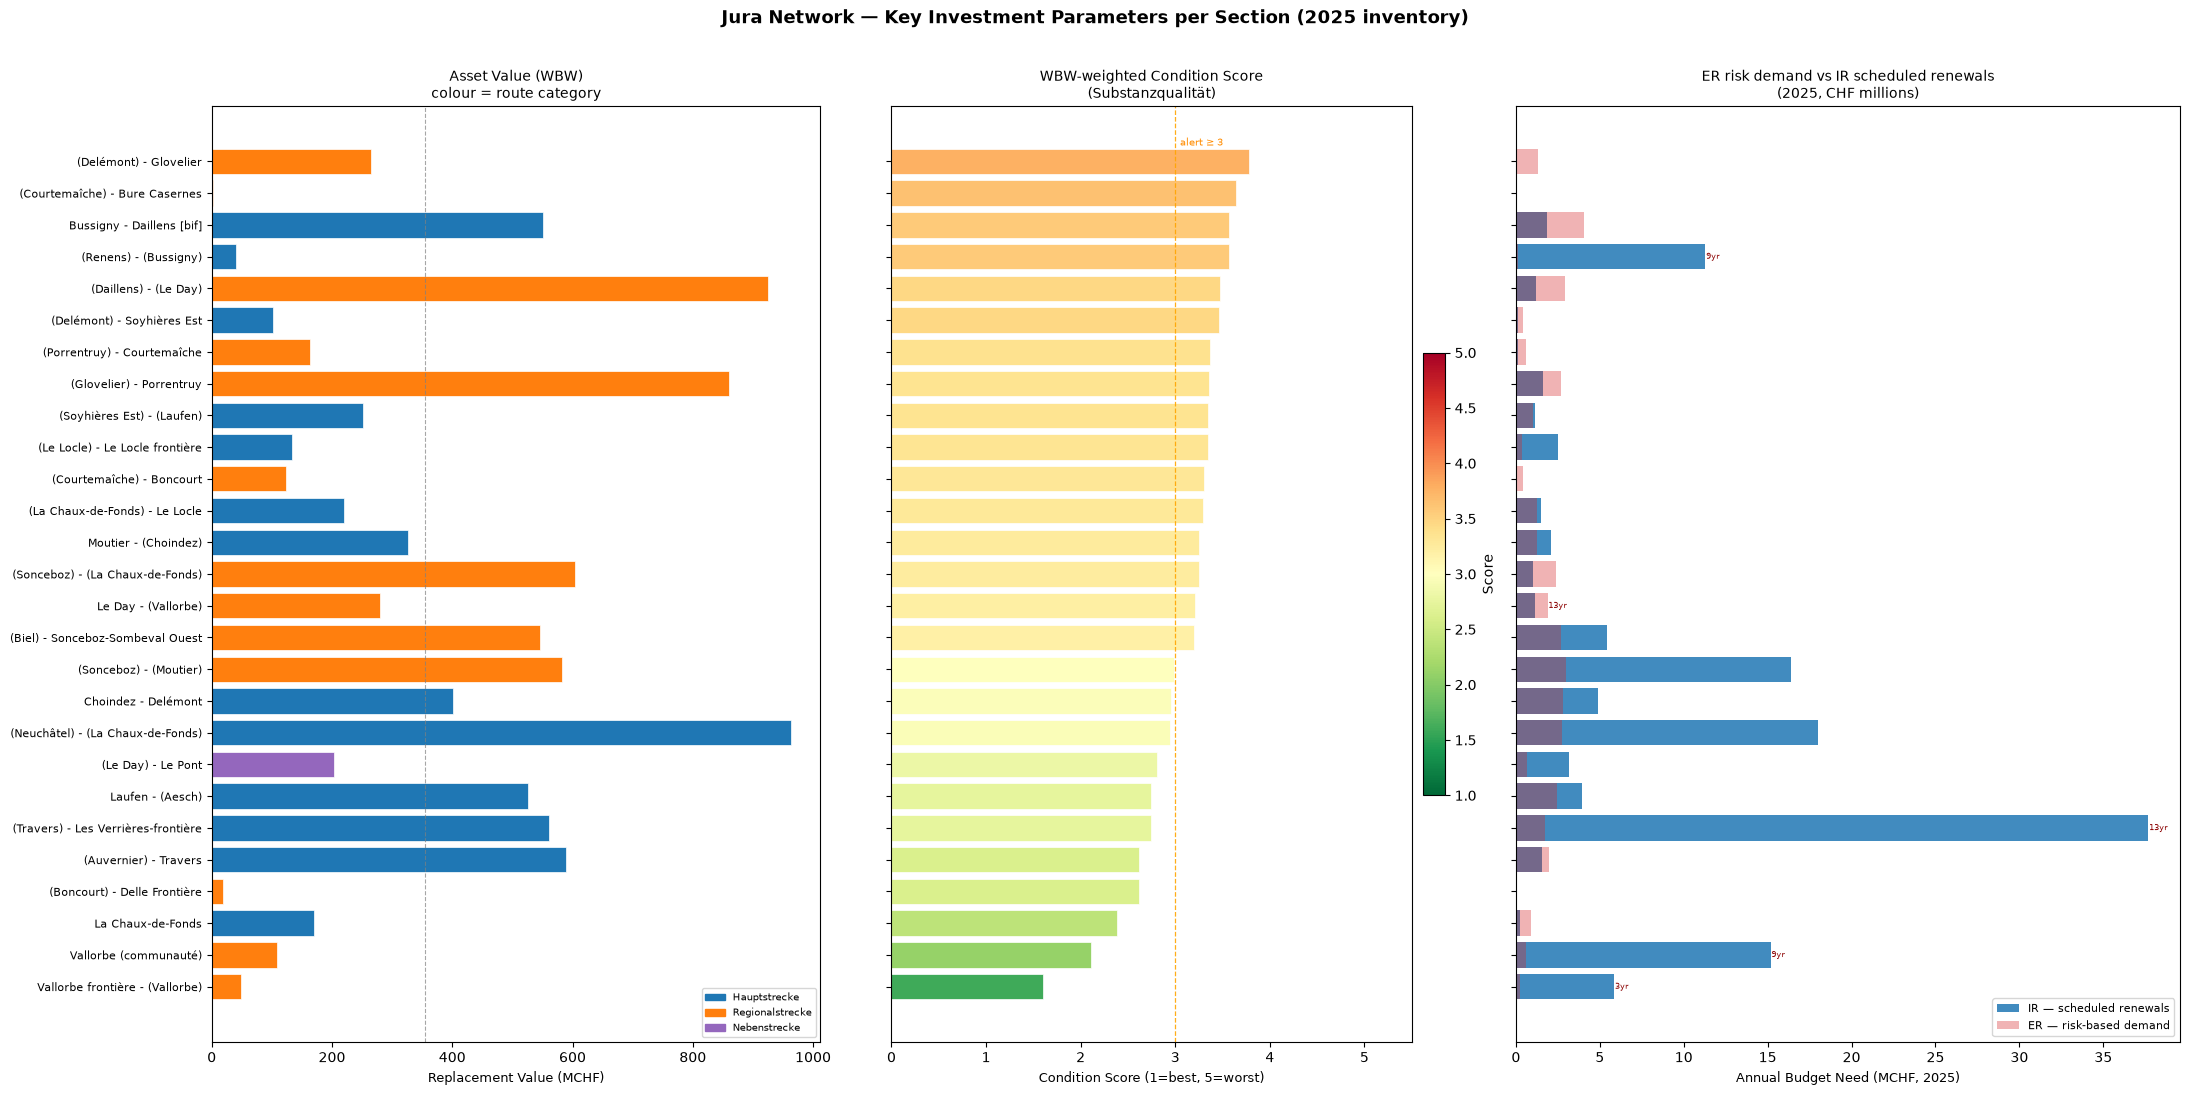

Figure saved → section_summary.png


In [9]:
plot_df = sec_summary.sort_values("substanz_score", ascending=True).copy()
labels  = plot_df["section_label"].tolist()
cat_color = {"Hauptstrecke": "#1f77b4", "Regionalstrecke": "#ff7f0e", "Nebenstrecke": "#9467bd"}
bar_colors = [cat_color.get(c, "#aec7e8") for c in plot_df["strecken_cat"]]

# Condition colormap: green (1) → red (5)
cmap = plt.cm.RdYlGn_r
score_norm = plt.Normalize(vmin=1, vmax=5)
cond_colors = [cmap(score_norm(s)) if not pd.isna(s) else (0.7, 0.7, 0.7, 1)
               for s in plot_df["substanz_score"]]

fig, axes = plt.subplots(1, 3, figsize=(22, max(8, len(labels) * 0.40)),
                         gridspec_kw={"width_ratios": [1.1, 1, 1.2]})
fig.suptitle("Jura Network — Key Investment Parameters per Section (2025 inventory)",
             fontsize=13, fontweight="bold", y=1.01)

y = list(range(len(labels)))

# ── Panel 1: Replacement Value ───────────────────────────────────────────────
ax = axes[0]
ax.barh(y, plot_df["wbw_MCHF"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Replacement Value (MCHF)", fontsize=9)
ax.set_title("Asset Value (WBW)\ncolour = route category", fontsize=10)
ax.axvline(plot_df["wbw_MCHF"].mean(), color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
patches = [mpatches.Patch(color=v, label=k) for k, v in cat_color.items()]
ax.legend(handles=patches, fontsize=7, loc="lower right")

# ── Panel 2: Condition Score ─────────────────────────────────────────────────
ax = axes[1]
ax.barh(y, plot_df["substanz_score"], color=cond_colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels([], fontsize=8)
ax.set_xlabel("Condition Score (1=best, 5=worst)", fontsize=9)
ax.set_title("WBW-weighted Condition Score\n(Substanzqualität)", fontsize=10)
ax.set_xlim(0, 5.5)
ax.axvline(3, color="orange", linestyle="--", linewidth=0.9, alpha=0.9)
ax.text(3.05, len(labels) - 0.5, "alert ≥ 3", fontsize=7, color="darkorange")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=score_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.04, pad=0.02,
             label="Score")

# ── Panel 3: ER demand vs IR scheduled renewals ──────────────────────────────
ax = axes[2]
er  = plot_df["er_need_MCHF"].fillna(0)
ir  = plot_df["ir_cost_MCHF"].fillna(0)
ax.barh(y, ir,  color="#1f77b4", alpha=0.85, label="IR — scheduled renewals")
ax.barh(y, er,  color="#d62728", alpha=0.35, label="ER — risk-based demand")
ax.set_yticks(y); ax.set_yticklabels([], fontsize=8)
ax.set_xlabel("Annual Budget Need (MCHF, 2025)", fontsize=9)
ax.set_title("ER risk demand vs IR scheduled renewals\n(2025, CHF millions)", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
# annotate remaining-life for urgency context
for i, rl in enumerate(plot_df["remaining_life_yr"]):
    if pd.notna(rl) and rl <= 15:
        ax.text(max(er.iloc[i], ir.iloc[i]) + 0.05, i,
                f"{int(rl)}yr", va="center", fontsize=6, color="darkred")

plt.tight_layout()
plt.savefig("section_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → section_summary.png")

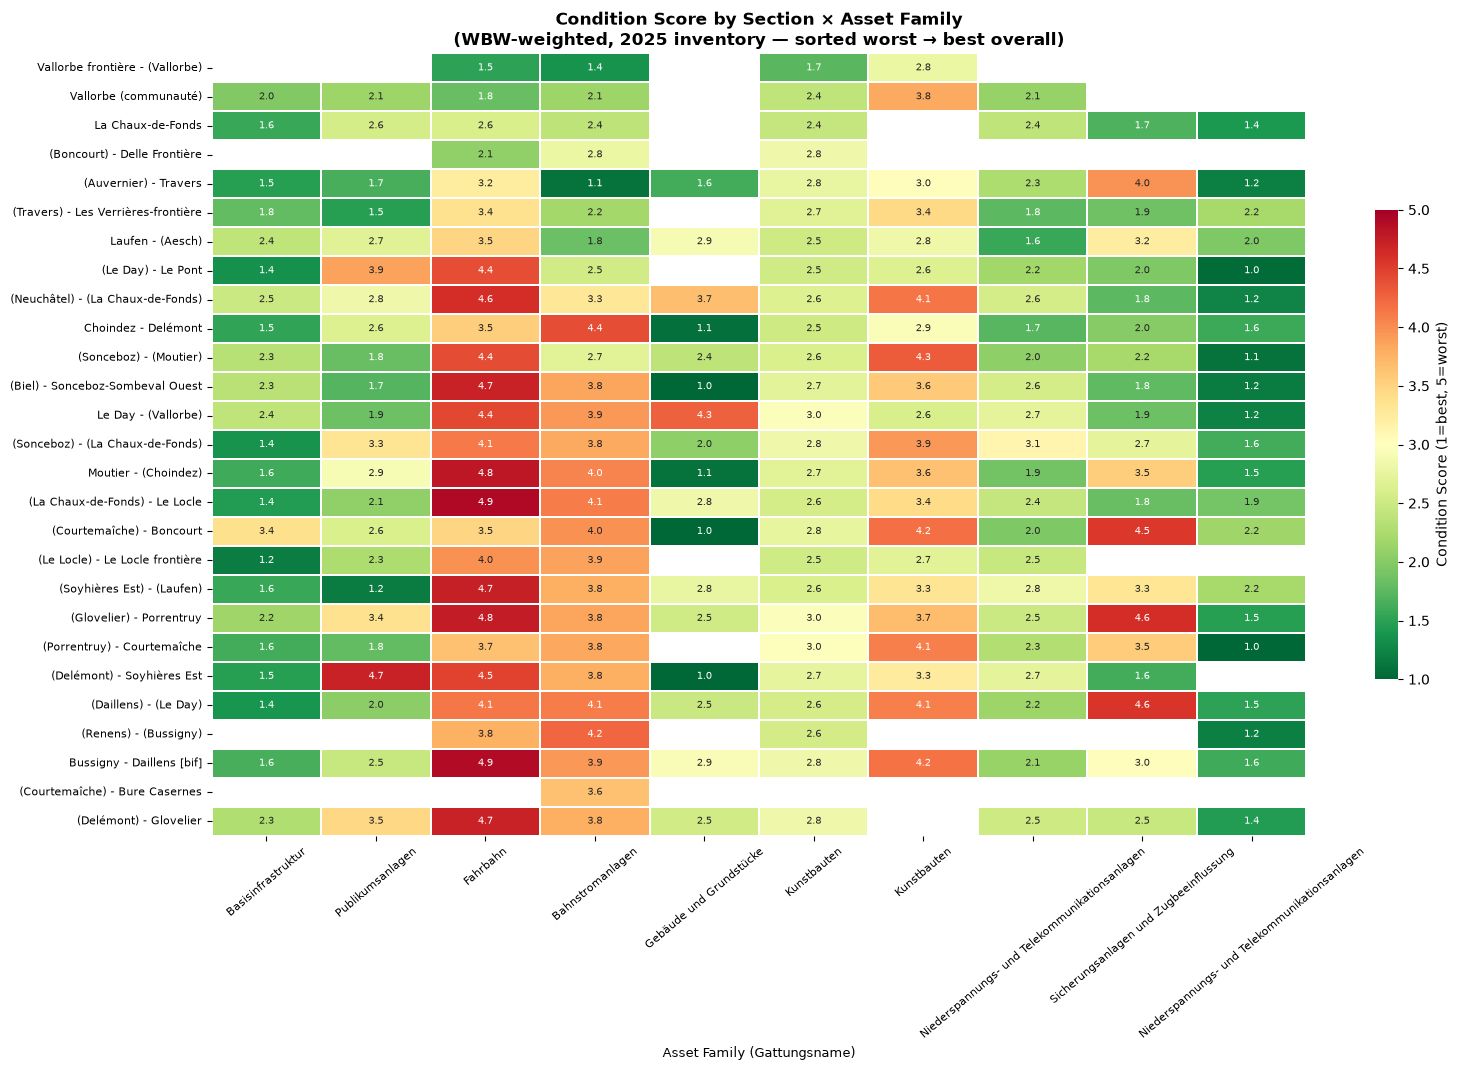

Heatmap saved → section_heatmap.png


In [10]:
# ── Heatmap: condition score by section × asset family ───────────────────────
# Use df_assets directly (all rows = 2025 Berichtsjahr inventory)
pivot = (
    df_assets
    .groupby([SEC, "Gattungsname"])
    .apply(lambda g: wavg(g, subst_col, wbw_col), include_groups=False)
    .unstack("Gattungsname")
)
# Keep sections in same order as bar chart (worst condition first)
available_sections = [s for s in plot_df[SEC].tolist() if s in pivot.index]
pivot = pivot.loc[available_sections]
pivot.index = plot_df.loc[plot_df[SEC].isin(available_sections), "section_label"].tolist()
# Shorten asset family labels
pivot.columns = pivot.columns.str.replace(r"^[A-Z]+ - ", "", regex=True)

fig2, ax2 = plt.subplots(figsize=(16, max(7, len(pivot) * 0.40)))
sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    vmin=1, vmax=5,
    linewidths=0.3, linecolor="white",
    annot=True, fmt=".1f", annot_kws={"size": 7},
    ax=ax2,
    cbar_kws={"label": "Condition Score (1=best, 5=worst)", "shrink": 0.6},
)
ax2.set_title("Condition Score by Section × Asset Family\n(WBW-weighted, 2025 inventory — sorted worst → best overall)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Asset Family (Gattungsname)", fontsize=9)
ax2.set_ylabel("")
ax2.tick_params(axis="x", labelrotation=40, labelsize=8)
ax2.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("section_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → section_heatmap.png")

TODO:
1. show distribution of condition score of assets from a section (or show how many critical aseets)
2. show condition score per section on a map (with assets if possible)

## 8 · Interactive Map — Condition Score per Section on OpenStreetMap

Sections are drawn as straight lines between their endpoint stations, colour-coded **green → red** for best → worst condition score.
Hover over a line for full KPIs. Also saved as `section_map.html`.

In [11]:
import folium
from branca.colormap import LinearColormap
import re

# ── Station coordinate lookup (WGS84) for the Jura sub-network ───────────────
STATION_COORDS = {
    "lausanne":             (46.5197,  6.6323),
    "renens":               (46.5331,  6.5858),
    "morges":               (46.5098,  6.4985),
    "yverdon":              (46.7784,  6.6408),
    "yverdon-les-bains":    (46.7784,  6.6408),
    "grandson":             (46.8082,  6.6503),
    "concise":              (46.8538,  6.7284),
    "neuchatel":            (47.0002,  6.9327),
    "neuchâtel":            (47.0002,  6.9327),
    "le landeron":          (47.0558,  7.0670),
    "cressier":             (47.0494,  7.0469),
    "biel":                 (47.1366,  7.2464),
    "bienne":               (47.1366,  7.2464),
    "biel/bienne":          (47.1366,  7.2464),
    "lyss":                 (47.0727,  7.3055),
    "kerzers":              (46.9891,  7.1956),
    "murten":               (46.9247,  7.1200),
    "morat":                (46.9247,  7.1200),
    "payerne":              (46.8207,  6.9383),
    "avenches":             (46.8781,  7.0433),
    "lengnau":              (47.1836,  7.3858),
    "bettlach":             (47.2047,  7.4089),
    "grenchen":             (47.1922,  7.3960),
    "grenchen nord":        (47.1977,  7.3938),
    "grenchen sud":         (47.1877,  7.3985),
    "solothurn":            (47.2088,  7.5367),
    "soleure":              (47.2088,  7.5367),
    "olten":                (47.3524,  7.9074),
    "aarau":                (47.3912,  8.0441),
    "basel":                (47.5596,  7.5886),
    "bale":                 (47.5596,  7.5886),
    "bâle":                 (47.5596,  7.5886),
    "laufen":               (47.4261,  7.4975),
    "aesch":                (47.4803,  7.5940),
    "dornach":              (47.4779,  7.6140),
    "liestal":              (47.4839,  7.7315),
    "pratteln":             (47.5220,  7.6999),
    "delemont":             (47.3666,  7.3446),
    "delémont":             (47.3666,  7.3446),
    "glovelier":            (47.3369,  7.2106),
    "porrentruy":           (47.4160,  7.0755),
    "boncourt":             (47.4899,  7.0050),
    "delle":                (47.5073,  6.9935),
    "courrendlin":          (47.3395,  7.3668),
    "courroux":             (47.3587,  7.3545),
    "bassecourt":           (47.3292,  7.2449),
    "undervelier":          (47.2989,  7.2056),
    "moutier":              (47.2772,  7.3695),
    "munster":              (47.2666,  7.3796),
    "münster":              (47.2666,  7.3796),
    "court":                (47.2530,  7.3564),
    "reconvilier":          (47.2381,  7.3200),
    "sonceboz":             (47.2020,  7.2860),
    "sonceboz-sombeval":    (47.2020,  7.2860),
    "tavannes":             (47.2200,  7.2070),
    "la chaux-de-fonds":    (47.0956,  6.8275),
    "chaux-de-fonds":       (47.0956,  6.8275),
    "la chaux de fonds":    (47.0956,  6.8275),
    "le locle":             (47.0563,  6.7519),
    "les ponts":            (46.9881,  6.6280),
    "saint-imier":          (47.1528,  6.9990),
    "st-imier":             (47.1528,  6.9990),
    "tramelan":             (47.2107,  7.1008),
    "saignelegier":         (47.2566,  7.0024),
    "saignelégier":         (47.2566,  7.0024),
    "le noirmont":          (47.2269,  6.9541),
    "noirmont":             (47.2269,  6.9541),
    "vallorbe":             (46.7136,  6.3717),
    "pontarlier":           (46.9052,  6.3549),
    "bern":                 (46.9481,  7.4474),
    "berne":                (46.9481,  7.4474),
    "zollikofen":           (47.0172,  7.4594),
    "münchenbuchsee":       (47.0280,  7.4280),
}

def _norm(s: str) -> str:
    return (s.lower()
             .replace("ü", "u").replace("ö", "o").replace("ä", "a")
             .replace("é", "e").replace("è", "e").replace("ê", "e")
             .replace("â", "a").replace("î", "i").strip())

def section_to_coords(label: str):
    parts = re.split(r"\s*[-–/]\s*", label)
    coords = []
    for part in parts:
        key = _norm(part)
        if key in STATION_COORDS:
            coords.append(STATION_COORDS[key])
            continue
        match = next((c for k, c in STATION_COORDS.items() if k in key or key in k), None)
        if match:
            coords.append(match)
    return coords

# ── Colour scale ──────────────────────────────────────────────────────────────
s_min = sec_summary["substanz_score"].min()
s_max = sec_summary["substanz_score"].max()
colormap = LinearColormap(
    colors=["#2ecc71", "#f1c40f", "#e74c3c"],
    vmin=s_min, vmax=s_max,
    caption=f"Condition score  {s_min:.2f} = best (green) · {s_max:.2f} = worst (red)",
)

# ── Build map ─────────────────────────────────────────────────────────────────
m = folium.Map(location=(47.1, 7.1), zoom_start=8, tiles="OpenStreetMap")
colormap.add_to(m)

matched, unmatched = [], []

for _, row in sec_summary.iterrows():
    label = row["section_label"]
    score = row["substanz_score"]
    if pd.isna(score):
        continue

    coords = section_to_coords(label)
    color  = colormap(score)
    tip = (
        f"<b>{label}</b><br>"
        f"Condition score: <b>{score:.2f}</b><br>"
        f"WBW: {row['wbw_MCHF']:.1f} MCHF<br>"
        f"ER need: {row['er_need_MCHF']:.2f} MCHF<br>"
        f"IR cost: {row['ir_cost_MCHF']:.2f} MCHF<br>"
        f"Rem. life: {row['remaining_life_yr']:.0f} yr<br>"
        f"Category: {row['strecken_cat']}"
    )

    if len(coords) >= 2:
        folium.PolyLine(
            locations=coords, color=color, weight=7, opacity=0.9,
            tooltip=folium.Tooltip(tip, sticky=True),
        ).add_to(m)
        for c in [coords[0], coords[-1]]:
            folium.CircleMarker(
                location=c, radius=5, color=color,
                fill=True, fill_color=color, fill_opacity=1.0,
                tooltip=folium.Tooltip(tip, sticky=True),
            ).add_to(m)
        matched.append(label)
    elif len(coords) == 1:
        folium.CircleMarker(
            location=coords[0], radius=9, color=color,
            fill=True, fill_color=color, fill_opacity=0.9,
            tooltip=folium.Tooltip(tip, sticky=True),
        ).add_to(m)
        matched.append(f"{label} (point only)")
    else:
        unmatched.append(label)

print(f"Sections rendered : {len(matched)}/{len(sec_summary)}")
if unmatched:
    print("Unmatched (add to STATION_COORDS to fix):")
    for u in unmatched:
        print(f"  {u}")

m.save("section_map.html")
print("Map saved → section_map.html")
display(m)

Sections rendered : 22/27
Unmatched (add to STATION_COORDS to fix):
  Bussigny - Daillens [bif]
  (Daillens) - (Le Day)
  (Le Day) - Le Pont
  (Auvernier) - Travers
  (Travers) - Les Verrières-frontière
Map saved → section_map.html
